In [1]:
.libPaths(c("C:/Users/matth/R/library", .libPaths()))

library(lme4)

Loading required package: Matrix



In [2]:
library(readr)
setwd("C:/Users/matth/OneDrive/Documents/NCU/Code Files")
sub <- read_csv("analysis/ambiguous_mixed-effects.csv")
spec(sub)
head(sub)

Rows: 468 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (6): sentence, model, query_mode, prompt_type, shot_type, context_type
lgl (1): correct

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


cols(
  sentence = col_character(),
  model = col_character(),
  query_mode = col_character(),
  prompt_type = col_character(),
  shot_type = col_character(),
  context_type = col_character(),
  correct = col_logical()
)

sentence,model,query_mode,prompt_type,shot_type,context_type,correct
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>
"They sat on the bank after withdrawing cash, watching the water flow by.",gpt,api,direct,zero,physical_environment,TRUE
"They sat on the bank after withdrawing cash, watching the water flow by.",gpt,api,cot,zero,physical_environment,TRUE
"They sat on the bank after withdrawing cash, watching the water flow by.",gpt,api,direct,few,physical_environment,FALSE
"They sat on the bank after withdrawing cash, watching the water flow by.",gpt,api,cot,few,physical_environment,TRUE
"The bank was quiet that morning, aside from the sound of ducks nearby.",gpt,api,direct,zero,physical_environment,TRUE
"The bank was quiet that morning, aside from the sound of ducks nearby.",gpt,api,cot,zero,physical_environment,TRUE


In [3]:
library(lme4)

sub$correct <- as.integer(sub$correct)

model <- glmer(
  correct ~ prompt_type + shot_type + query_mode + context_type + (1 | sentence),
  data = sub,
  family = binomial
)

print(summary(model), correlation = TRUE)

Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
"unable to evaluate scaled gradient"
Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
"Model failed to converge: degenerate  Hessian with 1 negative eigenvalues
  See ?lme4::convergence and ?lme4::troubleshooting."
Warning message in vcov.merMod(object, use.hessian = use.hessian):
"variance-covariance matrix computed from finite-difference Hessian is
not positive definite or contains NA values: falling back to var-cov estimated from RX"
Warning message in vcov.merMod(object, correlation = correlation, sigm = sig):
"variance-covariance matrix computed from finite-difference Hessian is
not positive definite or contains NA values: falling back to var-cov estimated from RX"


Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: binomial  ( logit )
Formula: correct ~ prompt_type + shot_type + query_mode + context_type +  
    (1 | sentence)
   Data: sub

      AIC       BIC    logLik -2*log(L)  df.resid 
    259.9     318.0    -116.0     231.9       454 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-9.3422  0.1070  0.2023  0.2870  1.1721 

Random effects:
 Groups   Name        Variance Std.Dev.
 sentence (Intercept) 0.5339   0.7307  
Number of obs: 468, groups:  sentence, 12

Fixed effects:
                                     Estimate Std. Error z value Pr(>|z|)   
(Intercept)                           3.26514    1.00714   3.242  0.00119 **
prompt_typedirect                    -0.55692    0.35818  -1.555  0.11998   
shot_typezero                        -0.75202    0.36704  -2.049  0.04047 * 
query_modemanual                     -0.41462    0.36925  -1.123  0.26149   
context_typeauditory_even


Correlation of fixed effects could have been required in summary()




Correlation of Fixed Effects:
                  (Intr) prmpt_ sht_ty qry_md cntxt_typd_ cntxt_typb_
prmpt_typdr       -0.225                                             
shot_typezr       -0.148  0.026                                      
query_mdmnl       -0.123  0.014 -0.244                               
cntxt_typd_       -0.639 -0.002 -0.003 -0.002                        
cntxt_typb_       -0.795  0.011  0.016  0.009  0.559                 
cntxt_typpr_      -0.639 -0.002 -0.003 -0.002  0.454       0.559     
cntxt_typphyscl_b  0.000  0.000  0.000  0.000  0.000       0.000     
cntxt_typphyscl_n -0.741 -0.002 -0.003 -0.002  0.526       0.647     
cntxt_typphyscl_m -0.735  0.021  0.028  0.015  0.512       0.631     
cntxt_typ__       -0.711  0.000  0.000  0.000  0.504       0.620     
cntxt_typsc_      -0.562 -0.004 -0.005 -0.003  0.400       0.492     
cntxt_typsp_       0.000  0.000  0.000  0.000  0.000       0.000     
                  cntxt_typpr_ cntxt_typphyscl_b cntxt_typp

In [8]:
exp(-0.75202)

[1] 0.4714133

In [9]:
table(sub$prompt_type, sub$correct)

table(sub$shot_type, sub$correct)

        
           0   1
  cot     17 217
  direct  26 208

      
         0   1
  few   22 290
  zero  21 135

In [10]:
aggregate(1 - correct ~ sentence, sub, sum)

sentence,1 - correct
<chr>,<dbl>
A small ring was the only thing found near the old bell.,2
"He adjusted his pitch slightly, hoping the crowd would respond better.",13
He hesitated to file while reviewing the materials spread across the table.,3
He placed the file on the table next to the metal tools.,6
It was a curveball pitch that nobody in the room was prepared to handle.,12
No one expected the tie to be the most talked-about part of the evening.,1
She noticed a faint ring left behind on the table after the guests departed.,0
She noticed the ring fade as soon as the bell stopped echoing.,2
She realized halfway through the pitch that her delivery was far too fast.,0


In [ ]:
model <- glmer(
  correct ~ prompt_type + shot_type + query_mode + context_type +
    (1 | sentence),
  data = sub,
  family = binomial,
  control = glmerControl(optimizer = "bobyqa")
)

Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
"unable to evaluate scaled gradient"
Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
"Model failed to converge: degenerate  Hessian with 2 negative eigenvalues
  See ?lme4::convergence and ?lme4::troubleshooting."


In [12]:
summary(model)

Warning message in vcov.merMod(object, use.hessian = use.hessian):
"variance-covariance matrix computed from finite-difference Hessian is
not positive definite or contains NA values: falling back to var-cov estimated from RX"
Warning message in vcov.merMod(object, correlation = correlation, sigm = sig):
"variance-covariance matrix computed from finite-difference Hessian is
not positive definite or contains NA values: falling back to var-cov estimated from RX"



Correlation matrix not shown by default, as p = 13 > 12.
Use print(obj, correlation=TRUE)  or
    vcov(obj)        if you need it




Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: binomial  ( logit )
Formula: correct ~ prompt_type + shot_type + query_mode + context_type +  
    (1 | sentence)
   Data: sub
Control: glmerControl(optimizer = "bobyqa")

      AIC       BIC    logLik -2*log(L)  df.resid 
    259.9     318.0    -116.0     231.9       454 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-9.3191  0.1073  0.2023  0.2870  1.1721 

Random effects:
 Groups   Name        Variance Std.Dev.
 sentence (Intercept) 0.5279   0.7266  
Number of obs: 468, groups:  sentence, 12

Fixed effects:
                                     Estimate Std. Error z value Pr(>|z|)   
(Intercept)                           3.26889    1.00435   3.255  0.00113 **
prompt_typedirect                    -0.55714    0.35803  -1.556  0.11968   
shot_typezero                        -0.74999    0.36687  -2.044  0.04093 * 
query_modemanual                     -0.41530    0.36907  

In [13]:
VarCorr(model)

 Groups   Name        Std.Dev.
 sentence (Intercept) 0.72657 

In [7]:
library(lme4)

sub$correct <- as.integer(sub$correct)
model <- glm(correct ~ prompt_type + shot_type + query_mode + context_type, 
data = sub, 
family = binomial)


print(summary(model), correlation = TRUE)


Call:
glm(formula = correct ~ prompt_type + shot_type + query_mode + 
    context_type, family = binomial, data = sub)

Coefficients:
                                     Estimate Std. Error z value Pr(>|z|)    
(Intercept)                         3.133e+00  6.782e-01   4.620 3.84e-06 ***
prompt_typedirect                  -5.277e-01  3.473e-01  -1.519   0.1287    
shot_typezero                      -7.087e-01  3.554e-01  -1.994   0.0461 *  
query_modemanual                   -3.923e-01  3.579e-01  -1.096   0.2731    
context_typeauditory_event          4.433e-01  9.534e-01   0.465   0.6420    
context_typebusiness_communication -9.124e-01  6.853e-01  -1.331   0.1830    
context_typepersonal_adornment      4.433e-01  9.534e-01   0.465   0.6420    
context_typephysical_binding        1.615e+01  1.066e+03   0.015   0.9879    
context_typephysical_environment    4.433e-01  8.002e-01   0.554   0.5796    
context_typephysical_motion        -1.772e+00  7.112e-01  -2.492   0.0127 *  
context

In [3]:
library(lme4)

sub$correct <- as.integer(sub$correct)

model <- glmer(
  correct ~ prompt_type + shot_type + query_mode + model + (1 | sentence),
  data = sub,
  family = binomial
)

print(summary(model), correlation = TRUE)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: binomial  ( logit )
Formula: correct ~ prompt_type + shot_type + query_mode + model + (1 |  
    sentence)
   Data: sub

      AIC       BIC    logLik -2*log(L)  df.resid 
    253.8     282.8    -119.9     239.8       461 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-6.8469  0.1011  0.1834  0.2890  1.0442 

Random effects:
 Groups   Name        Variance Std.Dev.
 sentence (Intercept) 2.33     1.526   
Number of obs: 468, groups:  sentence, 12

Fixed effects:
                  Estimate Std. Error z value Pr(>|z|)    
(Intercept)         3.4739     0.6718   5.171 2.33e-07 ***
prompt_typedirect  -0.5678     0.3607  -1.574   0.1155    
shot_typezero      -0.7647     0.3705  -2.064   0.0390 *  
query_modemanual   -0.4235     0.3723  -1.137   0.2554    
modeldeepseek       0.7349     0.4387   1.675   0.0939 .  
modelgpt            0.5197     0.4210   1.234   0.2171    
---


In [4]:
library(lme4)

sub$correct <- as.integer(sub$correct)

model <- glmer(
  correct ~ prompt_type + shot_type + query_mode + (1 | sentence),
  data = sub,
  family = binomial
)

print(summary(model), correlation = TRUE)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: binomial  ( logit )
Formula: correct ~ prompt_type + shot_type + query_mode + (1 | sentence)
   Data: sub

      AIC       BIC    logLik -2*log(L)  df.resid 
    253.0     273.7    -121.5     243.0       463 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-8.1882  0.1072  0.1939  0.2890  1.0990 

Random effects:
 Groups   Name        Variance Std.Dev.
 sentence (Intercept) 2.271    1.507   
Number of obs: 468, groups:  sentence, 12

Fixed effects:
                  Estimate Std. Error z value Pr(>|z|)    
(Intercept)         3.8353     0.6411   5.982  2.2e-09 ***
prompt_typedirect  -0.5600     0.3581  -1.564   0.1179    
shot_typezero      -0.7540     0.3677  -2.051   0.0403 *  
query_modemanual   -0.4176     0.3696  -1.130   0.2586    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Correlation of Fixed Effects:
            (Intr) prmpt_ sht_ty
prmpt

In [6]:
install.packages("DHARMa",repos = "https://cloud.r-project.org")

Installing package into 'C:/Users/matth/R/library'
(as 'lib' is unspecified)

also installing the dependencies 'sys', 'askpass', 'highr', 'xfun', 'tinytex', 'fs', 'rappdirs', 'curl', 'openssl', 'knitr', 'rmarkdown', 'yaml', 'jquerylib', 'memoise', 'sass', 'httr', 'htmlwidgets', 'lazyeval', 'crosstalk', 'data.table', 'promises', 'bslib', 'cachem', 'commonmark', 'fontawesome', 'httpuv', 'later', 'mime', 'otel', 'sourcetools', 'xtable', 'foreach', 'iterators', 'gap.datasets', 'plotly', 'shiny', 'plyr', 'doParallel', 'gap', 'ape', 'qgam'




package 'sys' successfully unpacked and MD5 sums checked
package 'askpass' successfully unpacked and MD5 sums checked
package 'highr' successfully unpacked and MD5 sums checked
package 'xfun' successfully unpacked and MD5 sums checked
package 'tinytex' successfully unpacked and MD5 sums checked
package 'fs' successfully unpacked and MD5 sums checked
package 'rappdirs' successfully unpacked and MD5 sums checked
package 'curl' successfully unpacked and MD5 sums checked
package 'openssl' successfully unpacked and MD5 sums checked
package 'knitr' successfully unpacked and MD5 sums checked
package 'rmarkdown' successfully unpacked and MD5 sums checked
package 'yaml' successfully unpacked and MD5 sums checked
package 'jquerylib' successfully unpacked and MD5 sums checked
package 'memoise' successfully unpacked and MD5 sums checked
package 'sass' successfully unpacked and MD5 sums checked
package 'httr' successfully unpacked and MD5 sums checked
package 'htmlwidgets' successfully unpacked and

Warning message:
"package 'DHARMa' was built under R version 4.6.1"
This is DHARMa 0.5.0. For overview type '?DHARMa'. For recent changes, type news(package = 'DHARMa') 

Note that the default setting in simulateResiduals was changed to conditional simulations since version 0.5.0. This is likely to change residual calculations for all hierarchical (in particular random effect) models. If you want to switch back to the old package version defaults, please use the argument simulateREs = "user-specified" in simulateResiduals(). For more details, see ?simulateREsiduals.


Attaching package: 'DHARMa'


The following object is masked from 'package:lme4':

    getData




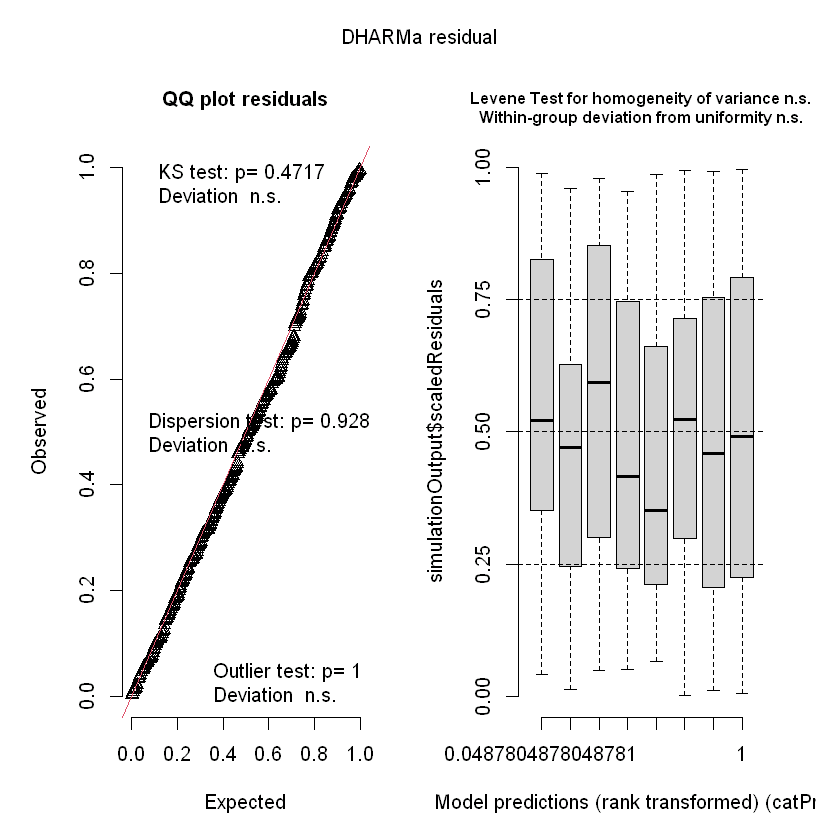

In [7]:
library(DHARMa)

sim <- simulateResiduals(model)
plot(sim)